# Calculate power spectrum multipoles for $mu(a) = 1 + \mu_0 \Omega_\mathrm{DE}/\Omega_\Lambda$

/n/home12/cgarciaquintero/.conda/envs/cosmodesi/lib/python3.10/site-packages/cosmoprimo/eisenstein_hu.py:25: UserWarning: EisensteinHuNoWiggleEngine cannot cope with massive neutrinos
  warnings.warn('{} cannot cope with massive neutrinos'.format(self.__class__.__name__))
/n/home12/cgarciaquintero/.conda/envs/cosmodesi/lib/python3.10/site-packages/cosmoprimo/eisenstein_hu.py:25: UserWarning: EisensteinHuNoWiggleEngine cannot cope with massive neutrinos
  warnings.warn('{} cannot cope with massive neutrinos'.format(self.__class__.__name__))


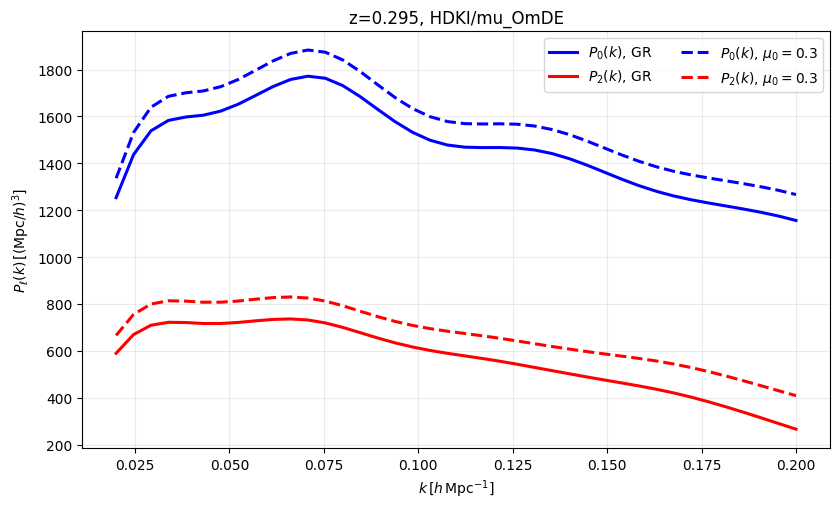

In [7]:
#!/usr/bin/env python3
import os
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Optional JAX settings (debug)
# -----------------------------
os.environ.setdefault("JAX_DISABLE_JIT", "1")  # set "0" for speed once validated
import jax
jax.config.update("jax_enable_x64", True)

# -----------------------------
# desilike / cosmoprimo imports
# -----------------------------
from desilike.theories import Cosmoprimo
from desilike.theories.galaxy_clustering import DirectPowerSpectrumTemplate
from desilike.theories.galaxy_clustering import fkptjaxTracerPowerSpectrumMultipoles
from desilike import parameter
from cosmoprimo.fiducial import DESI


# ============================================================
# USER SETTINGS
# ============================================================
z_eff = 0.295
k = np.linspace(0.02, 0.20, 40)
ells = (0, 2)

MG_model = "HDKI"
mg_variant = "mu_OmDE"
beyond_eds = True     # set False for EdS kernels
rescale_PS = False

# Two mu0 values to compare
mu0_a = 0.0
mu0_b = 0.3

# ---- nuisance params (STANDARD basis names) ----
freedom = "max"
prior_basis = "standard"   # alias -> standard_folps
tracer_tag = "BGS"
b3_coev = True
shotnoise_opt = 1e4

b1 = 1.70
b2 = -0.45
bs2 = 0.0
b3nl = 0.0
alpha0, alpha2, alpha4 = 3.0, -29.0, 0.0
ctilde = 0.0
alpha0shot, alpha2shot = 0.08, -8.0

# ---- cosmology ----
h = 0.6711
ombh2 = 0.022
omch2 = 0.122
As = 2e-9
ns = 0.965
Neff = 3.046
mnu = 0.06  # eV


# ============================================================
# Define cosmology class (ISiTGR via Cosmoprimo)
# ============================================================

# ----- (A) mu0 = 0.0 -----
cosmo = Cosmoprimo(engine="isitgr", MG_parameterization="muSigma", N_eff=Neff, m_ncdm=[mnu])

cosmo.init.params["h"].update(value=h)
cosmo.init.params["omega_b"].update(value=ombh2)
cosmo.init.params["omega_cdm"].update(value=omch2)
cosmo.init.params["logA"].update(value=float(np.log(1e10 * As)))
cosmo.init.params["n_s"].update(value=ns)

# ensure mu0 exists (depends on build); add if missing
if "mu0" not in cosmo.init.params:
    cosmo.init.params.data.append(parameter.Parameter(basename="mu0", value=0.0, fixed=True))
cosmo.init.params["mu0"].update(value=float(mu0_a), fixed=True)

# ============================================================
# Defining template (DirectPowerSpectrumTemplate)
# ============================================================
template = DirectPowerSpectrumTemplate(z=float(z_eff), fiducial=DESI(), cosmo=cosmo)
template.init.update(with_now="peakaverage")  # required by fkptjax path (needs pknow_dd)


# ============================================================
# Calling fkptjax tracer (mu0=0.0)
# ============================================================
theory_results = fkptjaxTracerPowerSpectrumMultipoles()
theory_results.init.update(
    freedom=freedom,
    prior_basis=prior_basis,
    tracer=tracer_tag,
    template=template,
    k=np.array(k, dtype=float),
    ells=list(ells),
    model=MG_model,
    mg_variant=mg_variant,
    b3_coev=bool(b3_coev),
    beyond_eds=bool(beyond_eds),
    rescale_PS=bool(rescale_PS),
    shotnoise=float(shotnoise_opt),
)

# fix nuisance params (standard basis names)
for name, val in dict(
    b1=b1, b2=b2, bs2=bs2, b3nl=b3nl,
    alpha0=alpha0, alpha2=alpha2, alpha4=alpha4,
    ctilde=ctilde, alpha0shot=alpha0shot, alpha2shot=alpha2shot
).items():
    if name in theory_results.init.params:
        theory_results.init.params[name].update(fixed=True, value=float(val))

Pell_GR = theory_results()  # evaluate

# unpack multipoles for mu0=0
Pell_GR = np.asarray(Pell_GR)
P0_GR = Pell_GR[0]
P2_GR = Pell_GR[1]

# ----- (B) mu0 = 0.3 -----
Pell_mu0 = theory_results(mu0=0.3)  # evaluate

# unpack multipoles for mu0=0
Pell_mu0 = np.asarray(Pell_mu0)
P0_mu0 = Pell_mu0[0]
P2_mu0 = Pell_mu0[1]

# ============================================================
# Plot: monopole + quadrupole, both mu0 values on one figure
# ============================================================
plt.figure(figsize=(8.5, 5.2))

plt.plot(k, k*P0_GR, lw=2.2, color='b', label=r"$P_0(k)$, GR")
plt.plot(k, k*P2_GR, lw=2.2, color='r', label=r"$P_2(k)$, GR")

plt.plot(k, k*P0_mu0, lw=2.2, color='b', ls="--", label=r"$P_0(k)$, $\mu_0=0.3$")
plt.plot(k, k*P2_mu0, lw=2.2, color='r', ls="--", label=r"$P_2(k)$, $\mu_0=0.3$")

plt.xlabel(r"$k\,[h\,\mathrm{Mpc}^{-1}]$")
plt.ylabel(r"$P_\ell(k)\,[(\mathrm{Mpc}/h)^3]$")
plt.title(fr"z={z_eff}, {MG_model}/{mg_variant}")
plt.grid(alpha=0.25)
plt.legend(ncols=2, fontsize=10)
plt.tight_layout()
plt.show()

# Calculate power spectrum multipoles & bispectrum tree-level for $mu(a) = 1 + \mu_0 \Omega_\mathrm{DE}/\Omega_\Lambda$

/n/home12/cgarciaquintero/.conda/envs/cosmodesi/lib/python3.10/site-packages/cosmoprimo/eisenstein_hu.py:25: UserWarning: EisensteinHuNoWiggleEngine cannot cope with massive neutrinos
  warnings.warn('{} cannot cope with massive neutrinos'.format(self.__class__.__name__))
/n/home12/cgarciaquintero/.conda/envs/cosmodesi/lib/python3.10/site-packages/cosmoprimo/eisenstein_hu.py:25: UserWarning: EisensteinHuNoWiggleEngine cannot cope with massive neutrinos
  warnings.warn('{} cannot cope with massive neutrinos'.format(self.__class__.__name__))
/n/home12/cgarciaquintero/.conda/envs/cosmodesi/lib/python3.10/site-packages/cosmoprimo/eisenstein_hu.py:25: UserWarning: EisensteinHuNoWiggleEngine cannot cope with massive neutrinos
  warnings.warn('{} cannot cope with massive neutrinos'.format(self.__class__.__name__))
/n/home12/cgarciaquintero/.conda/envs/cosmodesi/lib/python3.10/site-packages/cosmoprimo/eisenstein_hu.py:25: UserWarning: EisensteinHuNoWiggleEngine cannot cope with massive neutrin

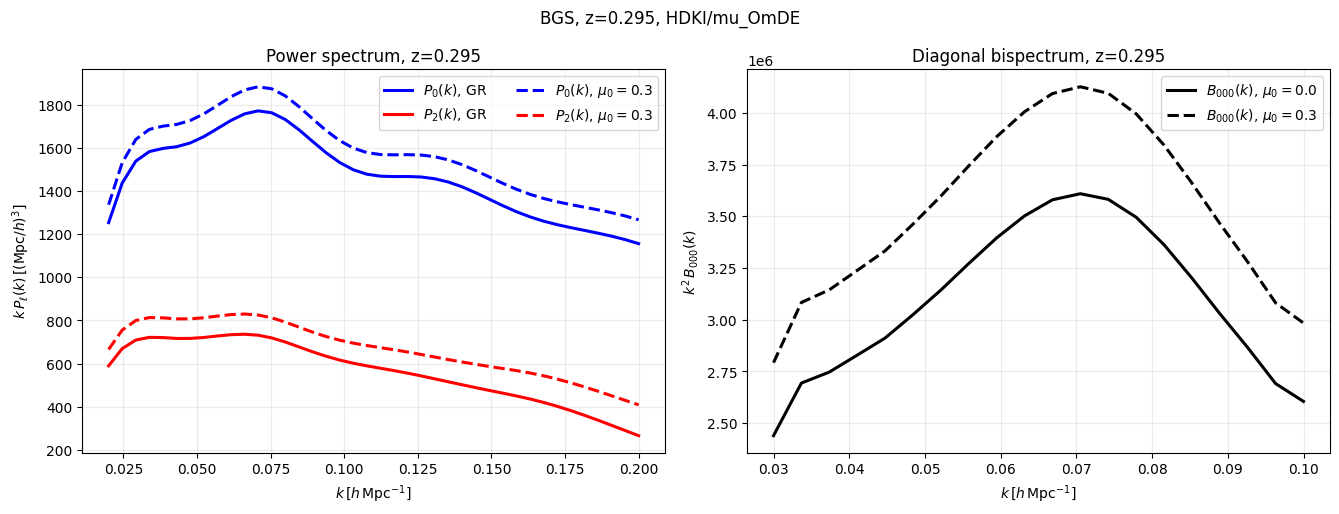

In [14]:
#!/usr/bin/env python3
import os
os.environ.setdefault("FOLPS_BACKEND", "jax")   # IMPORTANT: set before desilike imports
os.environ.setdefault("JAX_DISABLE_JIT", "1")   # set "0" for speed once validated

import numpy as np
import matplotlib.pyplot as plt

import jax
jax.config.update("jax_enable_x64", True)

from desilike.theories import Cosmoprimo
from desilike.theories.galaxy_clustering import DirectPowerSpectrumTemplate
from desilike.theories.galaxy_clustering import fkptjaxTracerPowerSpectrumMultipoles, fkptjaxTracerBispectrumMultipoles
from desilike import parameter
from cosmoprimo.fiducial import DESI


# ============================================================
# USER SETTINGS
# ============================================================
z_eff = 0.295
k = np.linspace(0.02, 0.20, 40)
ells = (0, 2)

# diagonal bispectrum grid (avoid too small k)
kB = np.linspace(0.03, 0.1, 20)
ells_bk = ((0, 0, 0),)  # B000 only

MG_model = "HDKI"
mg_variant = "mu_OmDE"
beyond_eds = True
rescale_PS = False

# Two mu0 values to compare
mu0_a = 0.0
mu0_b = 0.3

# ---- nuisance params (STANDARD basis names) ----
tracer_tag = "BGS"
freedom = "max"
prior_basis = "standard"   # alias -> standard_folps
b3_coev = True
shotnoise_opt = 1e4

# PS nuisances (standard)
b1 = 1.70
b2 = -0.45
bs2 = 0.0
b3nl = 0.0
alpha0, alpha2, alpha4 = 3.0, -29.0, 0.0
ctilde = 0.0
alpha0shot, alpha2shot = 0.08, -8.0

# Bk nuisances (standard_folps branch)
# (set to 0 for clean curves; change if you want)
c1, c2 = 0.0, 0.0
Pshot, Bshot = 0.0, 0.0
X_FoG_b = 0.0

# ---- cosmology ----
h = 0.6711
ombh2 = 0.022
omch2 = 0.122
As = 2e-9
ns = 0.965
Neff = 3.046
mnu = 0.0   # set back to 0.06 once you confirm no NaNs


# ============================================================
# Define cosmology class (ISiTGR via Cosmoprimo)  [mu0 = 0.0 baseline]
# ============================================================
cosmo = Cosmoprimo(engine="isitgr", MG_parameterization="muSigma", N_eff=Neff, m_ncdm=[mnu])

cosmo.init.params["h"].update(value=float(h))
cosmo.init.params["omega_b"].update(value=float(ombh2))
cosmo.init.params["omega_cdm"].update(value=float(omch2))
cosmo.init.params["logA"].update(value=float(np.log(1e10 * As)))
cosmo.init.params["n_s"].update(value=float(ns))

if "mu0" not in cosmo.init.params:
    cosmo.init.params.data.append(parameter.Parameter(basename="mu0", value=0.0, fixed=True))
cosmo.init.params["mu0"].update(value=float(mu0_a), fixed=True)


# ============================================================
# Defining template (DirectPowerSpectrumTemplate)
# ============================================================
template = DirectPowerSpectrumTemplate(z=float(z_eff), fiducial=DESI(), cosmo=cosmo)
template.init.update(with_now="peakaverage")  # required by fkptjax path (needs pknow_dd)


# ============================================================
# Calling fkptjax tracer (Power Spectrum) — ONE OBJECT ONLY
# ============================================================
theory_results = fkptjaxTracerPowerSpectrumMultipoles()
theory_results.init.update(
    freedom=freedom,
    prior_basis=prior_basis,
    tracer=tracer_tag,
    template=template,
    k=np.array(k, dtype=float),
    ells=list(ells),
    model=MG_model,
    mg_variant=mg_variant,
    b3_coev=bool(b3_coev),
    beyond_eds=bool(beyond_eds),
    rescale_PS=bool(rescale_PS),
    shotnoise=float(shotnoise_opt),
)

for name, val in dict(
    b1=b1, b2=b2, bs2=bs2, b3nl=b3nl,
    alpha0=alpha0, alpha2=alpha2, alpha4=alpha4,
    ctilde=ctilde, alpha0shot=alpha0shot, alpha2shot=alpha2shot
).items():
    if name in theory_results.init.params:
        theory_results.init.params[name].update(fixed=True, value=float(val))


# --- evaluate PS for mu0 = 0.0 ---
Pell_GR = theory_results()  # evaluate (mu0 already fixed in cosmo)
Pell_GR = np.asarray(Pell_GR)
P0_GR = Pell_GR[0]
P2_GR = Pell_GR[1]

# --- evaluate PS for mu0 = 0.3 (simple call, same object) ---
Pell_mu0 = theory_results(mu0=float(mu0_b))  # evaluate
Pell_mu0 = np.asarray(Pell_mu0)
P0_mu0 = Pell_mu0[0]
P2_mu0 = Pell_mu0[1]


# ============================================================
# Calling fkptjax tracer (Bispectrum diagonal) — ONE OBJECT ONLY
#   IMPORTANT: output stored in bk.power; __call__ may return None
# ============================================================
bk = fkptjaxTracerBispectrumMultipoles()
bk.init.update(
    tracer=tracer_tag,
    template=template,
    freedom="min",                  # matches your working reference
    prior_basis="standard",         # standard_folps branch
    basis="sugiyama",
    k=np.array(kB, float),          # diagonal grid (class builds k1k2T internally)
    ells=ells_bk,                   # B000 only
    model=MG_model,
    mg_variant=mg_variant,
    beyond_eds=True,
    renormalized=True,
    bias_scheme="folps",
    interpolation_method="linear",
    precision=[10, 8, 8],
    shotnoise=float(shotnoise_opt),
)

for name, val in dict(
    b1=b1, b2=b2, bs2=bs2,
    c1=c1, c2=c2,
    Pshot=Pshot, Bshot=Bshot,
    X_FoG_b=X_FoG_b,
).items():
    if name in bk.init.params:
        bk.init.params[name].update(fixed=True, value=float(val))


# --- evaluate Bk for mu0 = 0.0 ---
_ = bk(mu0=float(mu0_a))  # trigger calculate(); output in bk.power
Bout = getattr(bk, "power", None)

if Bout is None:
    B000_GR = np.full_like(kB, np.nan, dtype=float)
else:
    if isinstance(Bout, dict):
        for key in [(0, 0, 0), "B000", 0]:
            if key in Bout:
                Bout = Bout[key]
                break
    Bout = np.asarray(Bout)
    if Bout.ndim == 2 and Bout.shape[0] == 1 and Bout.shape[1] == len(kB):
        Bout = Bout[0]
    if Bout.ndim == 2 and Bout.shape[1] == 1 and Bout.shape[0] == len(kB):
        Bout = Bout[:, 0]
    B000_GR = np.asarray(Bout, dtype=float)
    if B000_GR.shape[0] != len(kB):
        B000_GR = np.full_like(kB, np.nan, dtype=float)

# --- evaluate Bk for mu0 = 0.3 (simple call, same object) ---
_ = bk(mu0=float(mu0_b))  # trigger calculate(); output in bk.power
Bout = getattr(bk, "power", None)

if Bout is None:
    B000_mu0 = np.full_like(kB, np.nan, dtype=float)
else:
    if isinstance(Bout, dict):
        for key in [(0, 0, 0), "B000", 0]:
            if key in Bout:
                Bout = Bout[key]
                break
    Bout = np.asarray(Bout)
    if Bout.ndim == 2 and Bout.shape[0] == 1 and Bout.shape[1] == len(kB):
        Bout = Bout[0]
    if Bout.ndim == 2 and Bout.shape[1] == 1 and Bout.shape[0] == len(kB):
        Bout = Bout[:, 0]
    B000_mu0 = np.asarray(Bout, dtype=float)
    if B000_mu0.shape[0] != len(kB):
        B000_mu0 = np.full_like(kB, np.nan, dtype=float)


# ============================================================
# Plot: PS (left) + diagonal B000 (right)
# ============================================================
fig, ax = plt.subplots(1, 2, figsize=(13.5, 5.2))

# ----- Left: Power spectrum -----
ax[0].plot(k, k * P0_GR, lw=2.2, color="b", label=r"$P_0(k)$, GR")
ax[0].plot(k, k * P2_GR, lw=2.2, color="r", label=r"$P_2(k)$, GR")

ax[0].plot(k, k * P0_mu0, lw=2.2, color="b", ls="--", label=fr"$P_0(k)$, $\mu_0={mu0_b}$")
ax[0].plot(k, k * P2_mu0, lw=2.2, color="r", ls="--", label=fr"$P_2(k)$, $\mu_0={mu0_b}$")

ax[0].set_xlabel(r"$k\,[h\,\mathrm{Mpc}^{-1}]$")
ax[0].set_ylabel(r"$k\,P_\ell(k)\,[(\mathrm{Mpc}/h)^3]$")
ax[0].set_title(fr"Power spectrum, z={z_eff}")
ax[0].grid(alpha=0.25)
ax[0].legend(ncols=2, fontsize=10)

# ----- Right: Diagonal bispectrum (B000 only) -----
ax[1].plot(kB, (kB ** 2) * B000_GR, lw=2.2, color="k", label=fr"$B_{{000}}(k)$, $\mu_0={mu0_a}$")
ax[1].plot(kB, (kB ** 2) * B000_mu0, lw=2.2, color="k", ls="--", label=fr"$B_{{000}}(k)$, $\mu_0={mu0_b}$")

ax[1].set_xlabel(r"$k\,[h\,\mathrm{Mpc}^{-1}]$")
ax[1].set_ylabel(r"$k^2\,B_{000}(k)$")
ax[1].set_title(fr"Diagonal bispectrum, z={z_eff}")
ax[1].grid(alpha=0.25)
ax[1].legend(ncols=1, fontsize=10)

fig.suptitle(fr"{tracer_tag}, z={z_eff}, {MG_model}/{mg_variant}", y=0.98)
plt.tight_layout()
plt.show()

# Calculate observables for the MG binning method

/n/home12/cgarciaquintero/.conda/envs/cosmodesi/lib/python3.10/site-packages/cosmoprimo/eisenstein_hu.py:25: UserWarning: EisensteinHuNoWiggleEngine cannot cope with massive neutrinos
  warnings.warn('{} cannot cope with massive neutrinos'.format(self.__class__.__name__))
/n/home12/cgarciaquintero/.conda/envs/cosmodesi/lib/python3.10/site-packages/cosmoprimo/eisenstein_hu.py:25: UserWarning: EisensteinHuNoWiggleEngine cannot cope with massive neutrinos
  warnings.warn('{} cannot cope with massive neutrinos'.format(self.__class__.__name__))
/n/home12/cgarciaquintero/.conda/envs/cosmodesi/lib/python3.10/site-packages/cosmoprimo/eisenstein_hu.py:25: UserWarning: EisensteinHuNoWiggleEngine cannot cope with massive neutrinos
  warnings.warn('{} cannot cope with massive neutrinos'.format(self.__class__.__name__))
/n/home12/cgarciaquintero/.conda/envs/cosmodesi/lib/python3.10/site-packages/cosmoprimo/eisenstein_hu.py:25: UserWarning: EisensteinHuNoWiggleEngine cannot cope with massive neutrin

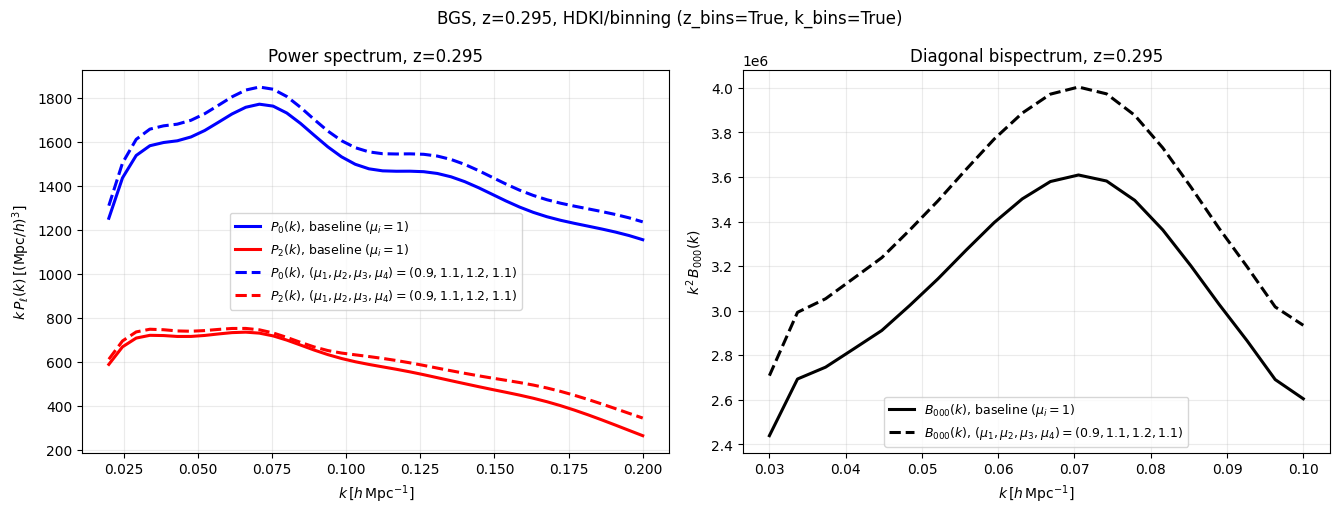

In [18]:
#!/usr/bin/env python3
import os
os.environ.setdefault("FOLPS_BACKEND", "jax")   # IMPORTANT: set before desilike imports
os.environ.setdefault("JAX_DISABLE_JIT", "1")   # set "0" for speed once validated

import numpy as np
import matplotlib.pyplot as plt

import jax
jax.config.update("jax_enable_x64", True)

from desilike.theories import Cosmoprimo
from desilike.theories.galaxy_clustering import DirectPowerSpectrumTemplate
from desilike.theories.galaxy_clustering import fkptjaxTracerPowerSpectrumMultipoles, fkptjaxTracerBispectrumMultipoles
from desilike import parameter
from cosmoprimo.fiducial import DESI


# ============================================================
# USER SETTINGS
# ============================================================
z_eff = 0.295
k = np.linspace(0.02, 0.20, 40)
ells = (0, 2)

# diagonal bispectrum grid (avoid too small k)
kB = np.linspace(0.03, 0.1, 20)
ells_bk = ((0, 0, 0),)  # B000 only

# --- MG model ---
MG_model = "HDKI"
mg_variant = "binning"   # <-- binning variant (as in your runner)

beyond_eds = True
rescale_PS = False

# --- binning toggles / defaults (match your runner logic) ---
redshift_bins = True
scale_bins = True
scale_bins_method = "traditional"

kc = 0.1

# fixed transition / GR-restoration knobs (runner defaults)
z_div = 1.0
z_TGR = 2.0
z_tw = 0.05
k_tw = 0.01
k_c = kc
Sigma1 = 1.0
Sigma2 = 1.0
Sigma3 = 1.0
Sigma4 = 1.0

# --- binning parameters you want (varied ones) ---
mu1 = 0.9
mu2 = 1.1
mu3 = 1.2
mu4 = 1.1

# baseline (GR-ish) values for mu-bins
mu1_GR = 1.0
mu2_GR = 1.0
mu3_GR = 1.0
mu4_GR = 1.0

# ---- nuisance params (STANDARD basis names) ----
tracer_tag = "BGS"
freedom = "max"
prior_basis = "standard"   # alias -> standard_folps
b3_coev = True
shotnoise_opt = 1e4

# PS nuisances (standard)
b1 = 1.70
b2 = -0.45
bs2 = 0.0
b3nl = 0.0
alpha0, alpha2, alpha4 = 3.0, -29.0, 0.0
ctilde = 0.0
alpha0shot, alpha2shot = 0.08, -8.0

# Bk nuisances (standard_folps branch)
c1, c2 = 0.0, 0.0
Pshot, Bshot = 0.0, 0.0
X_FoG_b = 0.0

# ---- cosmology ----
h = 0.6711
ombh2 = 0.022
omch2 = 0.122
As = 2e-9
ns = 0.965
Neff = 3.046
mnu = 0.0   # set back to 0.06 once you confirm no NaNs


# ============================================================
# Define cosmology class (ISiTGR via Cosmoprimo)
#   IMPORTANT: binning flags go into Cosmoprimo(...) (matches your runner)
# ============================================================
cosmo = Cosmoprimo(
    engine="isitgr",
    redshift_bins=bool(redshift_bins),
    scale_bins=bool(scale_bins),
    scale_bins_method=str(scale_bins_method),
    N_eff=Neff,
    m_ncdm=[mnu],
)

cosmo.init.params["h"].update(value=float(h))
cosmo.init.params["omega_b"].update(value=float(ombh2))
cosmo.init.params["omega_cdm"].update(value=float(omch2))
cosmo.init.params["logA"].update(value=float(np.log(1e10 * As)))
cosmo.init.params["n_s"].update(value=float(ns))

# Ensure mu bins exist; add if missing (varied in your runner unless force_GR)
for pname, v0 in [("mu1", mu1_GR), ("mu2", mu2_GR), ("mu3", mu3_GR), ("mu4", mu4_GR)]:
    if pname not in cosmo.init.params:
        cosmo.init.params.data.append(parameter.Parameter(basename=pname, value=float(v0), fixed=True))
    cosmo.init.params[pname].update(value=float(v0), fixed=True)

# Ensure transition / fixed knobs exist and set them to runner defaults
for pname, v0 in [
    ("z_div", z_div),
    ("z_TGR", z_TGR),
    ("z_tw", z_tw),
    ("k_tw", k_tw),
    ("k_c", k_c),
    ("Sigma1", Sigma1),
    ("Sigma2", Sigma2),
    ("Sigma3", Sigma3),
    ("Sigma4", Sigma4),
]:
    if pname not in cosmo.init.params:
        cosmo.init.params.data.append(parameter.Parameter(basename=pname, value=float(v0), fixed=True))
    cosmo.init.params[pname].update(value=float(v0), fixed=True)


# ============================================================
# Defining template (DirectPowerSpectrumTemplate)
# ============================================================
template = DirectPowerSpectrumTemplate(z=float(z_eff), fiducial=DESI(), cosmo=cosmo)
template.init.update(with_now="peakaverage")  # required by fkptjax path (needs pknow_dd)


# ============================================================
# Calling fkptjax tracer (Power Spectrum) — ONE OBJECT ONLY
# ============================================================
theory_results = fkptjaxTracerPowerSpectrumMultipoles()
theory_results.init.update(
    freedom=freedom,
    prior_basis=prior_basis,
    tracer=tracer_tag,
    template=template,
    k=np.array(k, dtype=float),
    ells=list(ells),
    model=MG_model,
    mg_variant=mg_variant,
    b3_coev=bool(b3_coev),
    beyond_eds=bool(beyond_eds),
    rescale_PS=bool(rescale_PS),
    shotnoise=float(shotnoise_opt),
)

for name, val in dict(
    b1=b1, b2=b2, bs2=bs2, b3nl=b3nl,
    alpha0=alpha0, alpha2=alpha2, alpha4=alpha4,
    ctilde=ctilde, alpha0shot=alpha0shot, alpha2shot=alpha2shot
).items():
    if name in theory_results.init.params:
        theory_results.init.params[name].update(fixed=True, value=float(val))


# --- evaluate PS for baseline (mu1..mu4 = 1.0) ---
Pell_GR = theory_results()  # evaluate (baseline fixed in cosmo)
Pell_GR = np.asarray(Pell_GR)
P0_GR = Pell_GR[0]
P2_GR = Pell_GR[1]

# --- evaluate PS for your binning values (simple call, same object) ---
Pell_bin = theory_results(mu1=float(mu1), mu2=float(mu2), mu3=float(mu3), mu4=float(mu4))
Pell_bin = np.asarray(Pell_bin)
P0_bin = Pell_bin[0]
P2_bin = Pell_bin[1]


# ============================================================
# Calling fkptjax tracer (Bispectrum diagonal) — ONE OBJECT ONLY
#   IMPORTANT: output stored in bk.power; __call__ may return None
# ============================================================
bk = fkptjaxTracerBispectrumMultipoles()
bk.init.update(
    tracer=tracer_tag,
    template=template,
    freedom="min",
    prior_basis="standard",
    basis="sugiyama",
    k=np.array(kB, float),
    ells=ells_bk,                   # B000 only
    model=MG_model,
    mg_variant=mg_variant,
    beyond_eds=True,
    renormalized=True,
    bias_scheme="folps",
    interpolation_method="linear",
    precision=[10, 8, 8],
    shotnoise=float(shotnoise_opt),
)

for name, val in dict(
    b1=b1, b2=b2, bs2=bs2,
    c1=c1, c2=c2,
    Pshot=Pshot, Bshot=Bshot,
    X_FoG_b=X_FoG_b,
).items():
    if name in bk.init.params:
        bk.init.params[name].update(fixed=True, value=float(val))


# --- evaluate Bk for baseline (mu1..mu4 = 1.0) ---
_ = bk()  # baseline already fixed in cosmo
Bout = getattr(bk, "power", None)

if Bout is None:
    B000_GR = np.full_like(kB, np.nan, dtype=float)
else:
    if isinstance(Bout, dict):
        for key in [(0, 0, 0), "B000", 0]:
            if key in Bout:
                Bout = Bout[key]
                break
    Bout = np.asarray(Bout)
    if Bout.ndim == 2 and Bout.shape[0] == 1 and Bout.shape[1] == len(kB):
        Bout = Bout[0]
    if Bout.ndim == 2 and Bout.shape[1] == 1 and Bout.shape[0] == len(kB):
        Bout = Bout[:, 0]
    B000_GR = np.asarray(Bout, dtype=float)
    if B000_GR.shape[0] != len(kB):
        B000_GR = np.full_like(kB, np.nan, dtype=float)

# --- evaluate Bk for your binning values (simple call, same object) ---
_ = bk(mu1=float(mu1), mu2=float(mu2), mu3=float(mu3), mu4=float(mu4))
Bout = getattr(bk, "power", None)

if Bout is None:
    B000_bin = np.full_like(kB, np.nan, dtype=float)
else:
    if isinstance(Bout, dict):
        for key in [(0, 0, 0), "B000", 0]:
            if key in Bout:
                Bout = Bout[key]
                break
    Bout = np.asarray(Bout)
    if Bout.ndim == 2 and Bout.shape[0] == 1 and Bout.shape[1] == len(kB):
        Bout = Bout[0]
    if Bout.ndim == 2 and Bout.shape[1] == 1 and Bout.shape[0] == len(kB):
        Bout = Bout[:, 0]
    B000_bin = np.asarray(Bout, dtype=float)
    if B000_bin.shape[0] != len(kB):
        B000_bin = np.full_like(kB, np.nan, dtype=float)


# ============================================================
# Plot: PS (left) + diagonal B000 (right)
# ============================================================
fig, ax = plt.subplots(1, 2, figsize=(13.5, 5.2))

# ----- Left: Power spectrum -----
ax[0].plot(k, k * P0_GR, lw=2.2, color="b", label=r"$P_0(k)$, baseline ($\mu_i=1$)")
ax[0].plot(k, k * P2_GR, lw=2.2, color="r", label=r"$P_2(k)$, baseline ($\mu_i=1$)")

ax[0].plot(k, k * P0_bin, lw=2.2, color="b", ls="--",
           label=fr"$P_0(k)$, $(\mu_1,\mu_2,\mu_3,\mu_4)=({mu1},{mu2},{mu3},{mu4})$")
ax[0].plot(k, k * P2_bin, lw=2.2, color="r", ls="--",
           label=fr"$P_2(k)$, $(\mu_1,\mu_2,\mu_3,\mu_4)=({mu1},{mu2},{mu3},{mu4})$")

ax[0].set_xlabel(r"$k\,[h\,\mathrm{Mpc}^{-1}]$")
ax[0].set_ylabel(r"$k\,P_\ell(k)\,[(\mathrm{Mpc}/h)^3]$")
ax[0].set_title(fr"Power spectrum, z={z_eff}")
ax[0].grid(alpha=0.25)
ax[0].legend(ncols=1, fontsize=9)

# ----- Right: Diagonal bispectrum (B000 only) -----
ax[1].plot(kB, (kB ** 2) * B000_GR, lw=2.2, color="k",
           label=r"$B_{000}(k)$, baseline ($\mu_i=1$)")
ax[1].plot(kB, (kB ** 2) * B000_bin, lw=2.2, color="k", ls="--",
           label=fr"$B_{{000}}(k)$, $(\mu_1,\mu_2,\mu_3,\mu_4)=({mu1},{mu2},{mu3},{mu4})$")

ax[1].set_xlabel(r"$k\,[h\,\mathrm{Mpc}^{-1}]$")
ax[1].set_ylabel(r"$k^2\,B_{000}(k)$")
ax[1].set_title(fr"Diagonal bispectrum, z={z_eff}")
ax[1].grid(alpha=0.25)
ax[1].legend(ncols=1, fontsize=9)

fig.suptitle(fr"{tracer_tag}, z={z_eff}, {MG_model}/{mg_variant} (z_bins={redshift_bins}, k_bins={scale_bins})", y=0.98)
plt.tight_layout()
plt.show()

/n/home12/cgarciaquintero/.conda/envs/cosmodesi/lib/python3.10/site-packages/cosmoprimo/eisenstein_hu.py:25: UserWarning: EisensteinHuNoWiggleEngine cannot cope with massive neutrinos
  warnings.warn('{} cannot cope with massive neutrinos'.format(self.__class__.__name__))
/n/home12/cgarciaquintero/.conda/envs/cosmodesi/lib/python3.10/site-packages/cosmoprimo/eisenstein_hu.py:25: UserWarning: EisensteinHuNoWiggleEngine cannot cope with massive neutrinos
  warnings.warn('{} cannot cope with massive neutrinos'.format(self.__class__.__name__))
/n/home12/cgarciaquintero/.conda/envs/cosmodesi/lib/python3.10/site-packages/cosmoprimo/eisenstein_hu.py:25: UserWarning: EisensteinHuNoWiggleEngine cannot cope with massive neutrinos
  warnings.warn('{} cannot cope with massive neutrinos'.format(self.__class__.__name__))
/n/home12/cgarciaquintero/.conda/envs/cosmodesi/lib/python3.10/site-packages/cosmoprimo/eisenstein_hu.py:25: UserWarning: EisensteinHuNoWiggleEngine cannot cope with massive neutrin

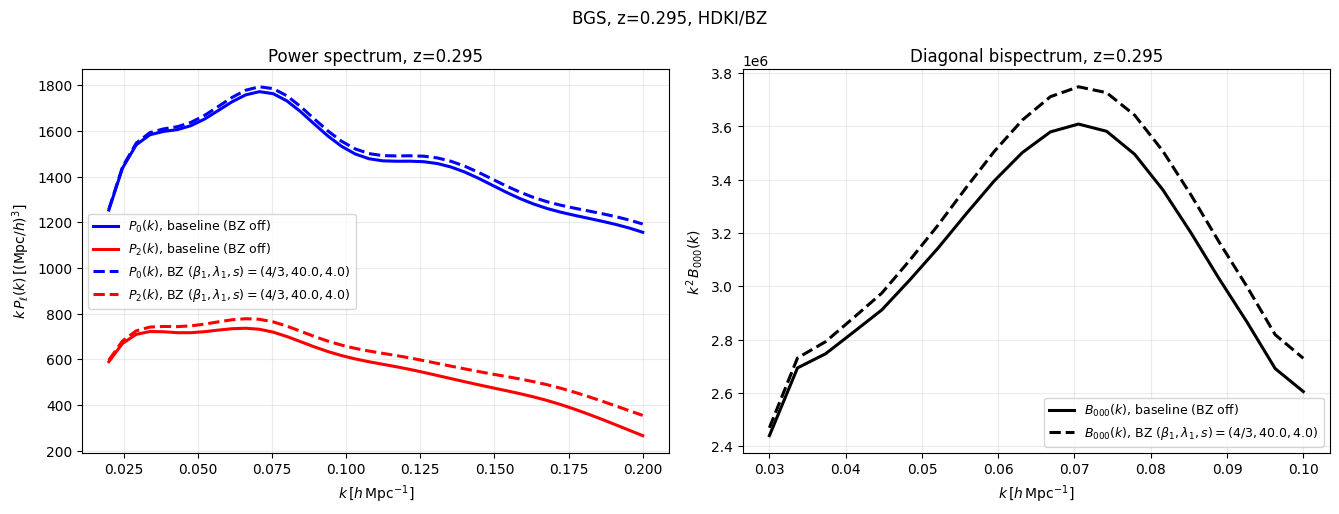

In [19]:
#!/usr/bin/env python3
import os
os.environ.setdefault("FOLPS_BACKEND", "jax")   # IMPORTANT: set before desilike imports
os.environ.setdefault("JAX_DISABLE_JIT", "1")   # set "0" for speed once validated

import numpy as np
import matplotlib.pyplot as plt

import jax
jax.config.update("jax_enable_x64", True)

from desilike.theories import Cosmoprimo
from desilike.theories.galaxy_clustering import DirectPowerSpectrumTemplate
from desilike.theories.galaxy_clustering import fkptjaxTracerPowerSpectrumMultipoles, fkptjaxTracerBispectrumMultipoles
from desilike import parameter
from cosmoprimo.fiducial import DESI


# ============================================================
# USER SETTINGS
# ============================================================
z_eff = 0.295
k = np.linspace(0.02, 0.20, 40)
ells = (0, 2)

# diagonal bispectrum grid (avoid too small k)
kB = np.linspace(0.03, 0.1, 20)
ells_bk = ((0, 0, 0),)  # B000 only

# --- MG model ---
MG_model = "HDKI"
mg_variant = "BZ"

beyond_eds = True
rescale_PS = False

# --- BZ parameters you want ---
beta_1_MG = 4.0 / 3.0
exp_s_MG  = 4.0
lambda_1_MG = 40.0

# baseline (GR-ish) values for BZ: beta_1=0 or lambda_1=0 effectively turns MG off
beta_1_GR = 0.0
exp_s_GR = 0.0
lambda_1_GR = 0.0

# ---- nuisance params (STANDARD basis names) ----
tracer_tag = "BGS"
freedom = "max"
prior_basis = "standard"   # alias -> standard_folps
b3_coev = True
shotnoise_opt = 1e4

# PS nuisances (standard)
b1 = 1.70
b2 = -0.45
bs2 = 0.0
b3nl = 0.0
alpha0, alpha2, alpha4 = 3.0, -29.0, 0.0
ctilde = 0.0
alpha0shot, alpha2shot = 0.08, -8.0

# Bk nuisances (standard_folps branch)
c1, c2 = 0.0, 0.0
Pshot, Bshot = 0.0, 0.0
X_FoG_b = 0.0

# ---- cosmology ----
h = 0.6711
ombh2 = 0.022
omch2 = 0.122
As = 2e-9
ns = 0.965
Neff = 3.046
mnu = 0.0   # set back to 0.06 once you confirm no NaNs


# ============================================================
# Define cosmology class (ISiTGR via Cosmoprimo)
#   Baseline = GR-like BZ: beta_1=lambda_1=exp_s=0
# ============================================================
cosmo = Cosmoprimo(
    engine="isitgr",
    N_eff=Neff,
    m_ncdm=[mnu],
)

cosmo.init.params["h"].update(value=float(h))
cosmo.init.params["omega_b"].update(value=float(ombh2))
cosmo.init.params["omega_cdm"].update(value=float(omch2))
cosmo.init.params["logA"].update(value=float(np.log(1e10 * As)))
cosmo.init.params["n_s"].update(value=float(ns))

# Ensure BZ params exist; add if missing
for pname, v0 in [("beta_1", beta_1_GR), ("lambda_1", lambda_1_GR), ("exp_s", exp_s_GR)]:
    if pname not in cosmo.init.params:
        cosmo.init.params.data.append(parameter.Parameter(basename=pname, value=float(v0), fixed=True))
    cosmo.init.params[pname].update(value=float(v0), fixed=True)


# ============================================================
# Defining template (DirectPowerSpectrumTemplate)
# ============================================================
template = DirectPowerSpectrumTemplate(z=float(z_eff), fiducial=DESI(), cosmo=cosmo)
template.init.update(with_now="peakaverage")  # required by fkptjax path (needs pknow_dd)


# ============================================================
# Calling fkptjax tracer (Power Spectrum) — ONE OBJECT ONLY
# ============================================================
theory_results = fkptjaxTracerPowerSpectrumMultipoles()
theory_results.init.update(
    freedom=freedom,
    prior_basis=prior_basis,
    tracer=tracer_tag,
    template=template,
    k=np.array(k, dtype=float),
    ells=list(ells),
    model=MG_model,
    mg_variant=mg_variant,
    b3_coev=bool(b3_coev),
    beyond_eds=bool(beyond_eds),
    rescale_PS=bool(rescale_PS),
    shotnoise=float(shotnoise_opt),
)

for name, val in dict(
    b1=b1, b2=b2, bs2=bs2, b3nl=b3nl,
    alpha0=alpha0, alpha2=alpha2, alpha4=alpha4,
    ctilde=ctilde, alpha0shot=alpha0shot, alpha2shot=alpha2shot
).items():
    if name in theory_results.init.params:
        theory_results.init.params[name].update(fixed=True, value=float(val))


# --- evaluate PS for baseline (GR-like BZ) ---
Pell_GR = theory_results()  # baseline fixed in cosmo
Pell_GR = np.asarray(Pell_GR)
P0_GR = Pell_GR[0]
P2_GR = Pell_GR[1]

# --- evaluate PS for BZ values (simple call, same object) ---
Pell_BZ = theory_results(beta_1=float(beta_1_MG), lambda_1=float(lambda_1_MG), exp_s=float(exp_s_MG))
Pell_BZ = np.asarray(Pell_BZ)
P0_BZ = Pell_BZ[0]
P2_BZ = Pell_BZ[1]


# ============================================================
# Calling fkptjax tracer (Bispectrum diagonal) — ONE OBJECT ONLY
#   IMPORTANT: output stored in bk.power; __call__ may return None
# ============================================================
bk = fkptjaxTracerBispectrumMultipoles()
bk.init.update(
    tracer=tracer_tag,
    template=template,
    freedom="min",
    prior_basis="standard",
    basis="sugiyama",
    k=np.array(kB, float),
    ells=ells_bk,                   # B000 only
    model=MG_model,
    mg_variant=mg_variant,
    beyond_eds=True,
    renormalized=True,
    bias_scheme="folps",
    interpolation_method="linear",
    precision=[10, 8, 8],
    shotnoise=float(shotnoise_opt),
)

for name, val in dict(
    b1=b1, b2=b2, bs2=bs2,
    c1=c1, c2=c2,
    Pshot=Pshot, Bshot=Bshot,
    X_FoG_b=X_FoG_b,
).items():
    if name in bk.init.params:
        bk.init.params[name].update(fixed=True, value=float(val))


# --- evaluate Bk for baseline (GR-like BZ) ---
_ = bk()  # baseline fixed in cosmo
Bout = getattr(bk, "power", None)

if Bout is None:
    B000_GR = np.full_like(kB, np.nan, dtype=float)
else:
    if isinstance(Bout, dict):
        for key in [(0, 0, 0), "B000", 0]:
            if key in Bout:
                Bout = Bout[key]
                break
    Bout = np.asarray(Bout)
    if Bout.ndim == 2 and Bout.shape[0] == 1 and Bout.shape[1] == len(kB):
        Bout = Bout[0]
    if Bout.ndim == 2 and Bout.shape[1] == 1 and Bout.shape[0] == len(kB):
        Bout = Bout[:, 0]
    B000_GR = np.asarray(Bout, dtype=float)
    if B000_GR.shape[0] != len(kB):
        B000_GR = np.full_like(kB, np.nan, dtype=float)

# --- evaluate Bk for BZ values (simple call, same object) ---
_ = bk(beta_1=float(beta_1_MG), lambda_1=float(lambda_1_MG), exp_s=float(exp_s_MG))
Bout = getattr(bk, "power", None)

if Bout is None:
    B000_BZ = np.full_like(kB, np.nan, dtype=float)
else:
    if isinstance(Bout, dict):
        for key in [(0, 0, 0), "B000", 0]:
            if key in Bout:
                Bout = Bout[key]
                break
    Bout = np.asarray(Bout)
    if Bout.ndim == 2 and Bout.shape[0] == 1 and Bout.shape[1] == len(kB):
        Bout = Bout[0]
    if Bout.ndim == 2 and Bout.shape[1] == 1 and Bout.shape[0] == len(kB):
        Bout = Bout[:, 0]
    B000_BZ = np.asarray(Bout, dtype=float)
    if B000_BZ.shape[0] != len(kB):
        B000_BZ = np.full_like(kB, np.nan, dtype=float)


# ============================================================
# Plot: PS (left) + diagonal B000 (right)
# ============================================================
fig, ax = plt.subplots(1, 2, figsize=(13.5, 5.2))

# ----- Left: Power spectrum -----
ax[0].plot(k, k * P0_GR, lw=2.2, color="b", label=r"$P_0(k)$, baseline (BZ off)")
ax[0].plot(k, k * P2_GR, lw=2.2, color="r", label=r"$P_2(k)$, baseline (BZ off)")

ax[0].plot(k, k * P0_BZ, lw=2.2, color="b", ls="--",
           label=fr"$P_0(k)$, BZ $(\beta_1,\lambda_1,s)=(4/3,{lambda_1_MG},{exp_s_MG})$")
ax[0].plot(k, k * P2_BZ, lw=2.2, color="r", ls="--",
           label=fr"$P_2(k)$, BZ $(\beta_1,\lambda_1,s)=(4/3,{lambda_1_MG},{exp_s_MG})$")

ax[0].set_xlabel(r"$k\,[h\,\mathrm{Mpc}^{-1}]$")
ax[0].set_ylabel(r"$k\,P_\ell(k)\,[(\mathrm{Mpc}/h)^3]$")
ax[0].set_title(fr"Power spectrum, z={z_eff}")
ax[0].grid(alpha=0.25)
ax[0].legend(ncols=1, fontsize=9)

# ----- Right: Diagonal bispectrum (B000 only) -----
ax[1].plot(kB, (kB ** 2) * B000_GR, lw=2.2, color="k",
           label=r"$B_{000}(k)$, baseline (BZ off)")
ax[1].plot(kB, (kB ** 2) * B000_BZ, lw=2.2, color="k", ls="--",
           label=fr"$B_{{000}}(k)$, BZ $(\beta_1,\lambda_1,s)=(4/3,{lambda_1_MG},{exp_s_MG})$")

ax[1].set_xlabel(r"$k\,[h\,\mathrm{Mpc}^{-1}]$")
ax[1].set_ylabel(r"$k^2\,B_{000}(k)$")
ax[1].set_title(fr"Diagonal bispectrum, z={z_eff}")
ax[1].grid(alpha=0.25)
ax[1].legend(ncols=1, fontsize=9)

fig.suptitle(fr"{tracer_tag}, z={z_eff}, {MG_model}/{mg_variant}", y=0.98)
plt.tight_layout()
plt.show()